In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')

In [ ]:
df = pd.read_csv("Hotel_bookings_final (1).csv")
df.head()

,customer_id,property_id,city,star_rating,booking_date,check_in_date,check_out_date,room_type,num_rooms_booked,stay_type,booking_channel,booking_value,costprice,markup,selling_price,payment_method,refund_status,refund_amount,channel_of_booking,booking_status,travel_date,cashback,coupon_redeem,Coupon USed?
0,492,3,San Francisco,4,4/1/2024,5/24/2024,5/26/2024,Standard,1,Leisure,Mobile App,19361.0,19361,5981,25342,PayPal,Yes,369.648995,Web,Confirmed,3/4/2024,5.374694,0.000000,No
1,180,3,Dallas,3,4/1/2024,5/10/2024,5/17/2024,Deluxe,1,Leisure,Mobile App,6137.0,6137,1896,8033,Bank Transfer,Yes,492.505903,Web,Confirmed,7/19/2024,7.161033,0.000000,No
2,50,5,Dallas,3,4/1/2024,5/31/2024,6/5/2024,Deluxe,1,Business,Web,22702.0,22702,7013,29715,Debit Card,Yes,0.000000,iOS,Confirmed,3/22/2024,0.000000,0.000000,No
3,294,3,Orlando,4,4/1/2024,4/18/2024,4/24/2024,Deluxe,3,Leisure,Web,34068.0,34068,10524,44592,Bank Transfer,Yes,545.541516,Android,Confirmed,11/24/2024,7.932170,24.500442,Yes
4,40,5,Seattle,5,4/1/2024,NaN,NaN,Deluxe,1,Leisure,Mobile App,12127.0,12127,3746,15873,Debit Card,Yes,211.367602,Web,Cancelled,3/2/2024,0.000000,0.000000,No


# 📊 Hotel Booking Data Analysis

This project analyzes booking trends, cancellation behavior, and business insights for a hotel booking platform.

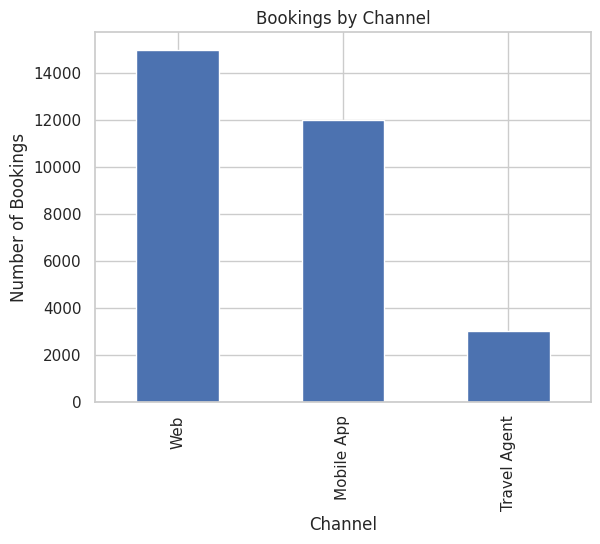

In [ ]:
df['booking_channel'].value_counts().plot(kind='bar')
plt.title("Bookings by Channel")
plt.xlabel("Channel")
plt.ylabel("Number of Bookings")
plt.show()

**Observation:**
- Web channel has the highest number of bookings
- Mobile App is the second most used platform
- Travel Agents contribute the least
- Customers prefer direct digital platforms for booking

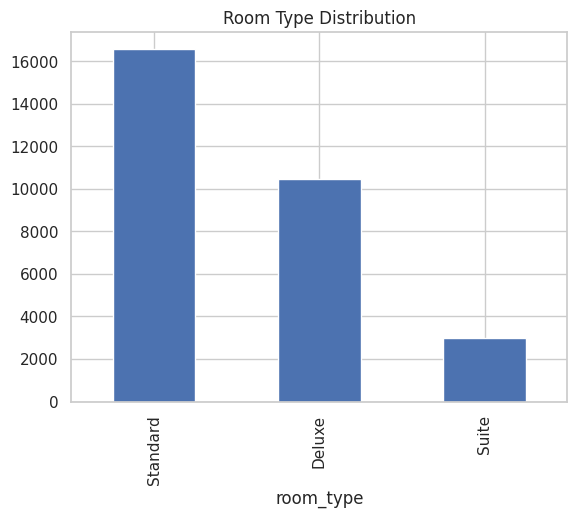

In [ ]:
df['room_type'].value_counts().plot(kind='bar')
plt.title("Room Type Distribution")
plt.show()

**Observation:**
- Most bookings are concentrated in a few room types
- Indicates customer preference for standard or mid-range rooms

In [ ]:
df['booking_status'].value_counts()

,count
booking_status,
Confirmed,21672
Cancelled,6070
Failed,2258


In [ ]:
cancel_rate = df[df['booking_status'] == 'Cancelled'].shape[0] / df.shape[0]
cancel_rate

0.20233333333333334

**Observation:**
- Cancellation rate is approximately 20%
- This indicates significant revenue leakage

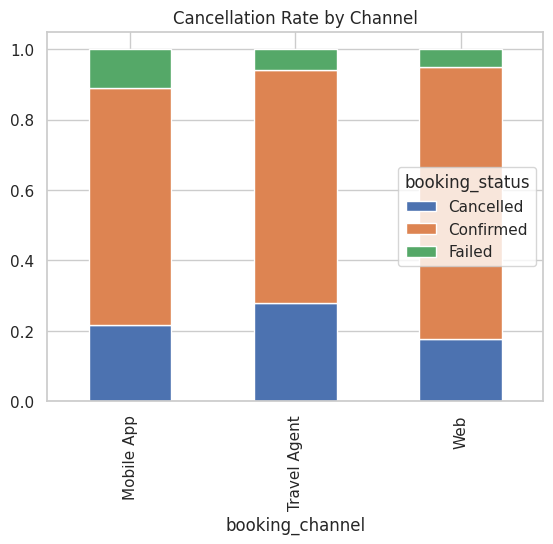

In [ ]:
pd.crosstab(df['booking_channel'], df['booking_status'], normalize='index').plot(kind='bar', stacked=True)
plt.title("Cancellation Rate by Channel")
plt.show()

**Observation:**
- Cancellation varies across channels
- Digital channels may have higher cancellations due to flexibility

In [ ]:
df['profit'] = df['selling_price'] - df['costprice']

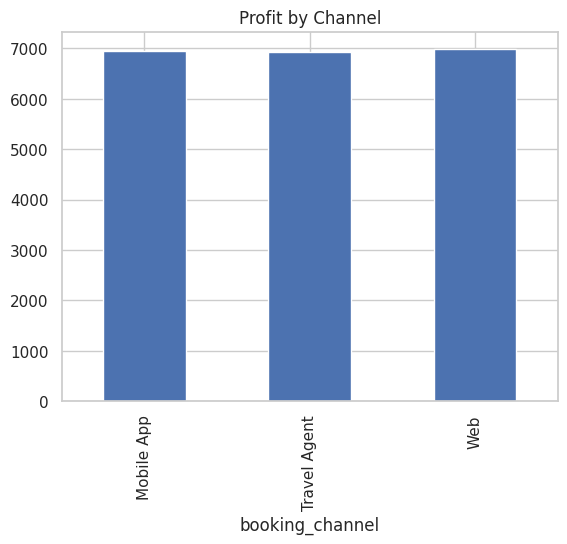

In [ ]:
df.groupby('booking_channel')['profit'].mean().plot(kind='bar')
plt.title("Profit by Channel")
plt.show()

In [ ]:
df['booking_date'] = pd.to_datetime(df['booking_date'])

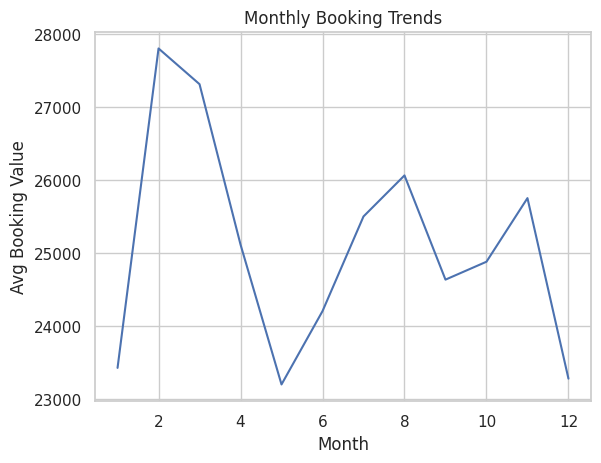

In [ ]:
df['month'] = df['booking_date'].dt.month
df.groupby('month')['booking_value'].mean().plot()
plt.title("Monthly Booking Trends")
plt.xlabel("Month")
plt.ylabel("Avg Booking Value")
plt.show()

**Insight:**
- Booking values show clear seasonal variation across months
- Peak booking values occur in early months (Feb–March), indicating high demand periods
- Mid-year (May–June) shows a dip, suggesting lower travel activity
- Indicates strong seasonality in customer demand and pricing

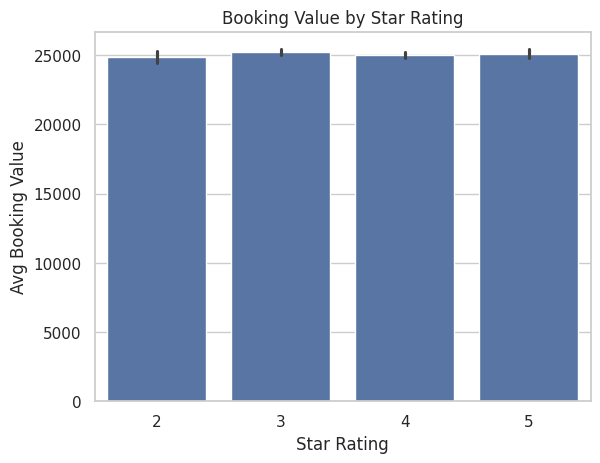

In [35]:
sns.barplot(x='star_rating', y='booking_value', data=df)
plt.title("Booking Value by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Avg Booking Value")
plt.show()

**Insight:**
- Booking values are relatively consistent across different star ratings
- Indicates that customers spend similar amounts regardless of hotel category
- Suggests pricing is standardized across property types rather than premium-driven

Revenue is driven by volume, not by premium pricing

## Key Insights

- Web channel contributes ~50% of total bookings, making it the primary revenue driver
- Mobile App accounts for ~40% of bookings, indicating strong mobile adoption trends
- Travel Agents contribute <10%, showing limited scalability of offline channels

- Cancellation rate is ~20%, meaning 1 in every 5 bookings is lost, creating significant revenue leakage

- Cancellation rates appear relatively consistent across channels, suggesting that cancellations are driven more by customer behavior than channel-specific issues

- Profit margins are relatively similar across channels, indicating pricing consistency but limited differentiation in channel strategy

- Booking values peak during certain months (e.g., Feb–March), highlighting strong seasonality in demand

## Advanced Insight

- Despite higher booking volume from Web and Mobile channels, cancellation rates remain significant (~20%), indicating that growth in volume is not translating proportionally into realized revenue.
- This suggests a need to focus not just on acquisition, but on conversion quality and booking commitment.

## Business Recommendations

### 1. Reduce Revenue Leakage
- Introduce tiered cancellation penalties based on proximity to check-in
- Promote non-refundable bookings with price incentives
- Implement behavioral nudges (reminders, urgency messaging)

### 2. Optimize Channel Strategy
- Focus marketing spend on Web & Mobile channels due to higher scalability
- Re-evaluate the role of Travel Agents due to low contribution

### 3. Improve Conversion Quality
- Introduce stricter booking confirmation mechanisms
- Offer incentives for committed bookings (e.g., prepaid discounts)

### 4. Leverage Seasonality
- Increase pricing during peak demand months
- Launch targeted promotions during low-demand periods